Original Shape : (569, 30)
PCA Shape : (569, 4)

Explained Variance Ratio
PC1: 0.4427
PC2: 0.1897
PC3: 0.0939
PC4: 0.0660

Total Variance Preserved: 0.7923850582446097
Logistic Regression

Accuracy : 0.9737
Precision: 1.0
Recall   : 0.9286
F1 Score : 0.963

Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



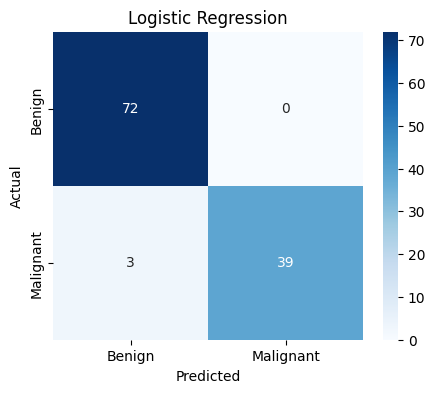

SVM (RBF)

Accuracy : 0.9474
Precision: 0.9737
Recall   : 0.881
F1 Score : 0.925

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.99      0.96        72
           1       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



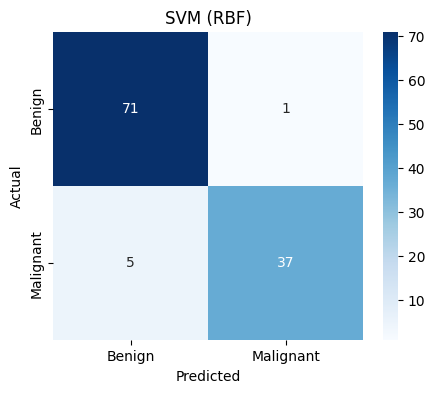

KNN

Accuracy : 0.9386
Precision: 0.973
Recall   : 0.8571
F1 Score : 0.9114

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        72
           1       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



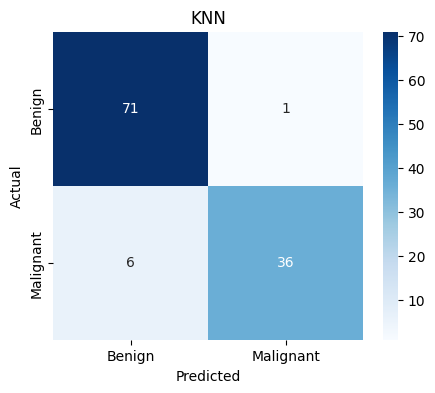

Decision Tree

Accuracy : 0.9211
Precision: 0.9231
Recall   : 0.8571
F1 Score : 0.8889

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        72
           1       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



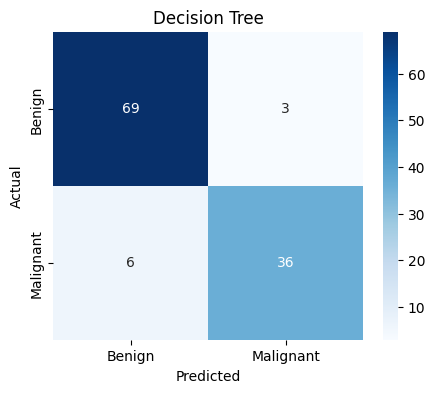

Random Forest

Accuracy : 0.9561
Precision: 0.9744
Recall   : 0.9048
F1 Score : 0.9383

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



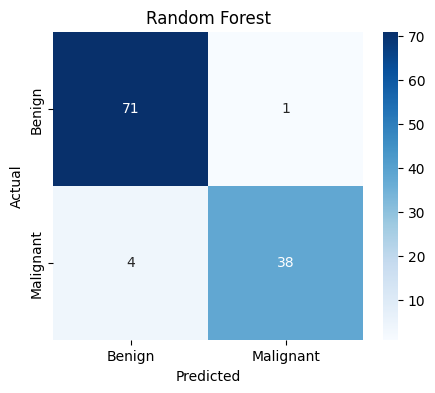

Gradient Boosting

Accuracy : 0.9474
Precision: 1.0
Recall   : 0.8571
F1 Score : 0.9231

Classification Report
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        72
           1       1.00      0.86      0.92        42

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



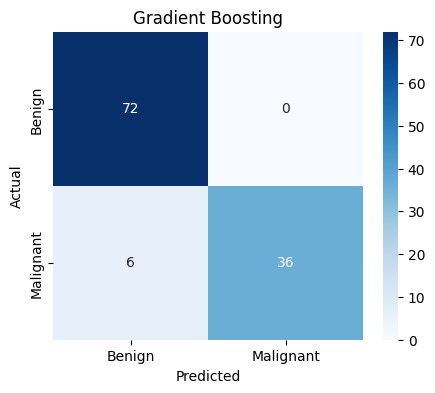

Naive Bayes

Accuracy : 0.9035
Precision: 0.9189
Recall   : 0.8095
F1 Score : 0.8608

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.96      0.93        72
           1       0.92      0.81      0.86        42

    accuracy                           0.90       114
   macro avg       0.91      0.88      0.89       114
weighted avg       0.90      0.90      0.90       114



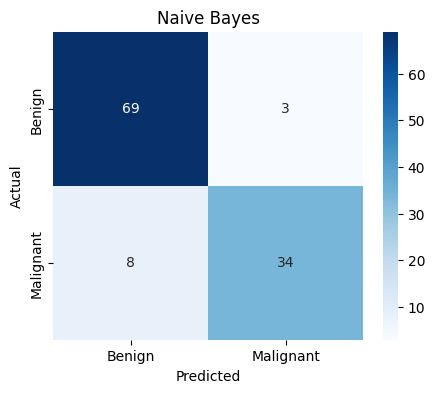


Overall Model Performance

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.973684   1.000000  0.928571  0.962963
4        Random Forest  0.956140   0.974359  0.904762  0.938272
1            SVM (RBF)  0.947368   0.973684  0.880952  0.925000
5    Gradient Boosting  0.947368   1.000000  0.857143  0.923077
2                  KNN  0.938596   0.972973  0.857143  0.911392
3        Decision Tree  0.921053   0.923077  0.857143  0.888889
6          Naive Bayes  0.903509   0.918919  0.809524  0.860759


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

# -----------------------------------
# Load Dataset
# -----------------------------------
df = pd.read_csv("breast-cancer.csv")

# Drop unnecessary columns
df.drop(["id"], axis=1, inplace=True)

# Encode target
df["diagnosis"] = df["diagnosis"].map({"M":1, "B":0})

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

# -----------------------------------
# Standardize Features
# -----------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------------
# PCA (Reduce to 4 Components)
# -----------------------------------
pca = PCA(n_components=4)

X_pca = pca.fit_transform(X_scaled)

print("Original Shape :", X.shape)
print("PCA Shape :", X_pca.shape)

print("\nExplained Variance Ratio")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f}")

print("\nTotal Variance Preserved:",
      pca.explained_variance_ratio_.sum())

# -----------------------------------
# Train-Test Split
# -----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------------
# Models
# -----------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (RBF)": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}

# -----------------------------------
# Train & Evaluate
# -----------------------------------
results = []

for name, model in models.items():

    print("="*70)
    print(name)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print("\nAccuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Benign","Malignant"],
        yticklabels=["Benign","Malignant"]
    )

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# -----------------------------------
# Final Comparison
# -----------------------------------
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

print("\nOverall Model Performance\n")
print(results_df.sort_values(by="Accuracy", ascending=False))